# ACS Attitude: QBJ → RA/Dec/PA

Retrieves the `SCF_AC_SDR_QBJ_1–4` and `SCF_AC_SDR_MODE` mnemonics from MAST EDB
via `roman-telem`, pivots to wide format, then computes RA/Dec/PA using
`roman_attitude` from `roman-opup-tools`.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from dotenv import load_dotenv

load_dotenv(Path("../.env"))

# roman-opup-tools for quaternion → RA/Dec/PA
sys.path.insert(0, str(Path("../../roman-opup-tools/src").resolve()))
from roman_opup_tools.roman_attitude import roman_attitude

# roman-mast-tools for telemetry queries
sys.path.insert(0, str(Path("..").resolve()))
from roman_telem import MASTEngDBQuery

In [2]:
# ── Query parameters ──────────────────────────────────────────────────────────
START = "2026-09-05"
END   = "2026-09-07"

MNEMONICS = [
    "SCF_AC_SDR_QBJ_1",
    "SCF_AC_SDR_QBJ_2",
    "SCF_AC_SDR_QBJ_3",
    "SCF_AC_SDR_QBJ_4",
    "SCF_AC_SDR_MODE",
]

In [5]:
# ── Fetch telemetry (parallel, returns wide DataFrame) ───────────────────────
query = MASTEngDBQuery()   # reads MAST_API_TOKEN from .env

wide = query.query_multiple_mnemonics(MNEMONICS, START, END)
# Returns ObsTime-indexed DataFrame with one column per mnemonic
wide.index = pd.to_datetime(wide.index)
wide = wide.sort_index().reset_index().rename(columns={"ObsTime": "time"})
print(f"Shape: {wide.shape}  |  columns: {list(wide.columns)}")

Mnemonic SCF_AC_SDR_MODE query completed.
Mnemonic SCF_AC_SDR_QBJ_3 query completed.
Mnemonic SCF_AC_SDR_QBJ_1 query completed.
Mnemonic SCF_AC_SDR_QBJ_2 query completed.
Mnemonic SCF_AC_SDR_QBJ_4 query completed.
DF combine processing time:  0.0052279999999989
Shape: (691202, 6)  |  columns: ['time', 'SCF_AC_SDR_MODE', 'SCF_AC_SDR_QBJ_3', 'SCF_AC_SDR_QBJ_1', 'SCF_AC_SDR_QBJ_2', 'SCF_AC_SDR_QBJ_4']


In [6]:
wide.head()

,time,SCF_AC_SDR_MODE,SCF_AC_SDR_QBJ_3,SCF_AC_SDR_QBJ_1,SCF_AC_SDR_QBJ_2,SCF_AC_SDR_QBJ_4
0,2026-09-04 23:59:59.904,ENG,0.598772,-0.620395,-0.231576,0.450505
1,2026-09-05 00:00:00.153,ENG,0.598772,-0.620395,-0.231576,0.450504
2,2026-09-05 00:00:00.403,ENG,0.598772,-0.620395,-0.231576,0.450504
3,2026-09-05 00:00:00.653,ENG,0.598772,-0.620396,-0.231576,0.450504
4,2026-09-05 00:00:00.903,ENG,0.598772,-0.620396,-0.231577,0.450504


In [7]:
# ── qbj_to_radecpa (adapted from hkt_attitude_plots.py) ──────────────────────
# Expects SCF_AC_SDR_QBJ_1..4 columns; roman_attitude takes [x, y, z, w] scalar-last.

Q_COLS = ["SCF_AC_SDR_QBJ_1", "SCF_AC_SDR_QBJ_2", "SCF_AC_SDR_QBJ_3", "SCF_AC_SDR_QBJ_4"]

def qbj_to_radecpa(df_in, norm_tol=1e-3):
    q = df_in[Q_COLS].values.astype(float)
    norms = np.linalg.norm(np.where(np.isnan(q), 0.0, q), axis=1)
    valid = (
        ~np.any(np.isnan(q) | np.isinf(q), axis=1)
        & (np.abs(norms - 1.0) <= norm_tol)
        & (np.abs(q[:, :3]).sum(axis=1) > norm_tol)
    )
    df_v = df_in[valid].copy()
    results = [roman_attitude(row) for row in q[valid]]
    ra_arr, dec_arr, pa_arr = np.array(results).T
    df_v["ra_deg"]  = ra_arr
    df_v["dec_deg"] = dec_arr
    df_v["pa_deg"]  = pa_arr
    return df_v

att = qbj_to_radecpa(wide)
att = att.dropna(subset=["ra_deg", "dec_deg", "pa_deg"]).reset_index(drop=True)
print(f"{len(att):,} rows with valid quaternions ({len(att)/max(len(wide),1)*100:.1f}%)")
att[["time", "ra_deg", "dec_deg", "pa_deg"]].head()

691,202 rows with valid quaternions (100.0%)


,time,ra_deg,dec_deg,pa_deg
0,2026-09-04 23:59:59.904,78.003998,-32.296344,81.635560
1,2026-09-05 00:00:00.153,78.004007,-32.296336,81.635570
2,2026-09-05 00:00:00.403,78.003972,-32.296346,81.635589
3,2026-09-05 00:00:00.653,78.003970,-32.296326,81.635621
4,2026-09-05 00:00:00.903,78.003976,-32.296306,81.635632


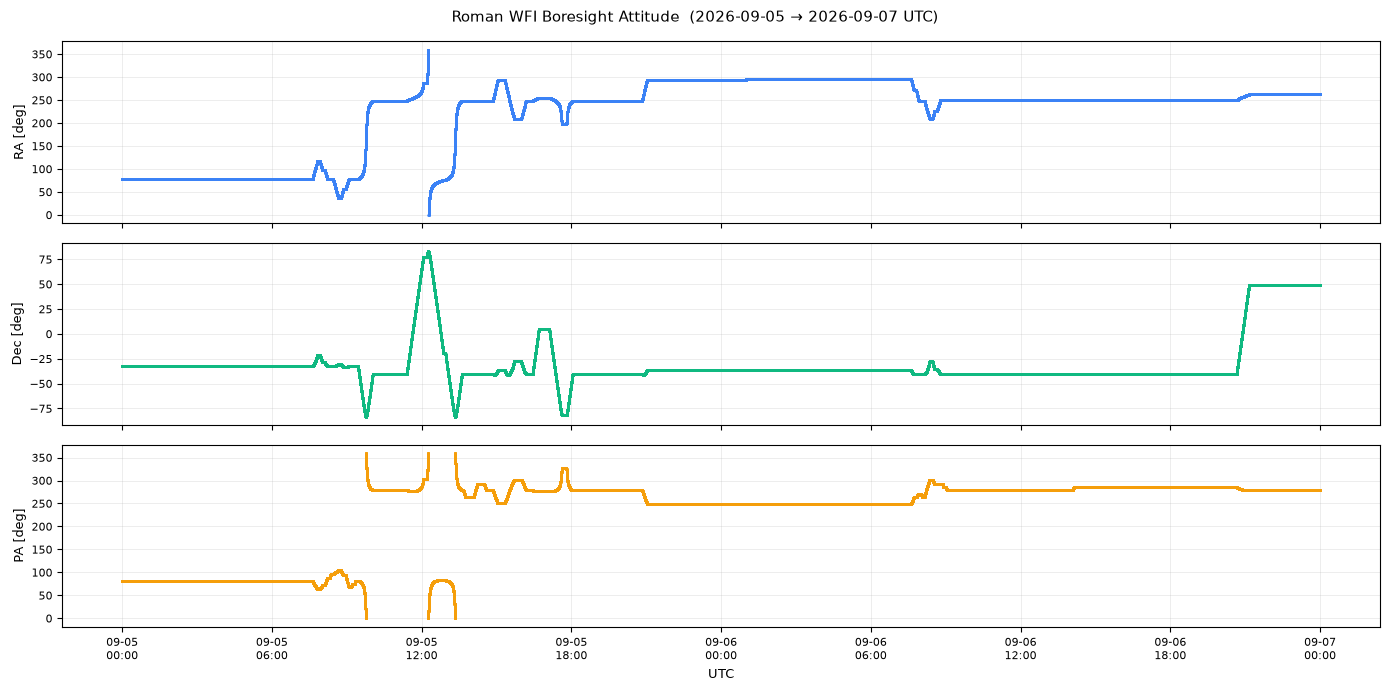

In [8]:
# ── Plot: RA, Dec, PA vs. time ────────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(14, 7), sharex=True)
fig.suptitle(
    f"Roman WFI Boresight Attitude  ({START} → {END} UTC)",
    fontsize=11,
)

panels = [
    ("ra_deg",  "RA [deg]",  "#3B82F6"),
    ("dec_deg", "Dec [deg]", "#10B981"),
    ("pa_deg",  "PA [deg]",  "#F59E0B"),
]

for ax, (col, ylabel, color) in zip(axes, panels):
    ax.plot(att["time"], att[col], ".", ms=1.5, lw=0, color=color, alpha=0.7, rasterized=True)
    ax.set_ylabel(ylabel, fontsize=9)
    ax.grid(True, lw=0.4, alpha=0.4)
    ax.tick_params(labelsize=8)

axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%m-%d\n%H:%M"))
axes[-1].xaxis.set_major_locator(mdates.AutoDateLocator())
axes[-1].set_xlabel("UTC", fontsize=9)

fig.tight_layout()
plt.show()

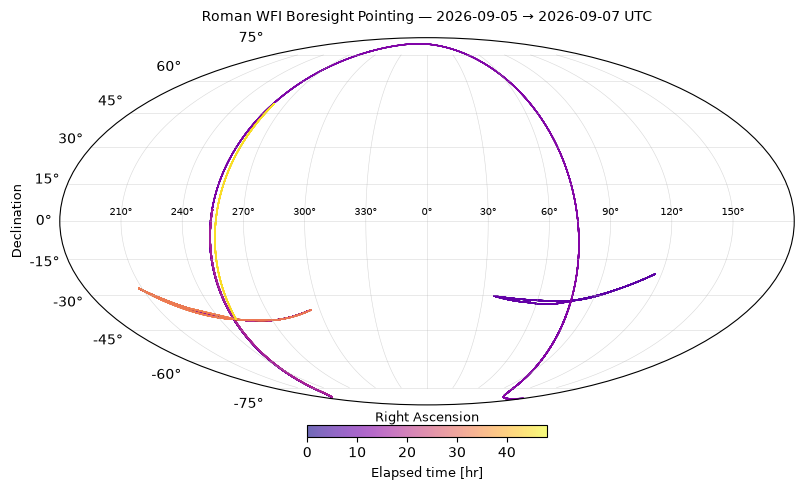

In [9]:
# ── Mollweide sky map ─────────────────────────────────────────────────────────
t0 = att["time"].min()
elapsed_hr = (att["time"] - t0).dt.total_seconds() / 3600.0

ra_rad  = np.radians(att["ra_deg"].values)
ra_rad  = np.where(ra_rad > np.pi, ra_rad - 2 * np.pi, ra_rad)
dec_rad = np.radians(att["dec_deg"].values)

fig2 = plt.figure(figsize=(12, 5))
ax2  = fig2.add_subplot(111, projection="mollweide")
sc   = ax2.scatter(ra_rad, dec_rad, c=elapsed_hr, cmap="plasma",
                   s=1, alpha=0.6, linewidths=0, rasterized=True)
cbar = fig2.colorbar(sc, ax=ax2, orientation="horizontal", pad=0.05, fraction=0.03)
cbar.set_label("Elapsed time [hr]", fontsize=9)
ax2.set_title(
    f"Roman WFI Boresight Pointing — {START} → {END} UTC",
    fontsize=10, pad=12,
)
ax2.set_xlabel("Right Ascension", fontsize=9)
ax2.set_ylabel("Declination", fontsize=9)
ax2.grid(True, lw=0.4, alpha=0.5)
ra_ticks  = np.radians([-150, -120, -90, -60, -30, 0, 30, 60, 90, 120, 150])
ra_labels = [f"{(d % 360):.0f}°" for d in np.degrees(ra_ticks)]
ax2.set_xticks(ra_ticks)
ax2.set_xticklabels(ra_labels, fontsize=7)
fig2.tight_layout()
plt.show()